##Predição de diagnósticos de leucemias por meio da análise de lâminas de sangue periférico

###Projeto de conclusão da pós-graduação em BI Master na PUC-Rio


##### Aluno: [Maria Rita de Sousa](https://github.com/link_do_github](https://github.com/Marri-Sousa))

##### Orientadora:  [Professora Manoela Kohler](https://github.com/manoelakohler).

### Bibliotecas

In [1]:
!pip install scorecardpy
!pip install shap -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

import scorecardpy as sc
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings('ignore')

In [3]:
path = kagglehub.dataset_download("lorenzozoppelletto/financial-risk-for-loan-approval")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'financial-risk-for-loan-approval' dataset.
Path to dataset files: /kaggle/input/financial-risk-for-loan-approval


In [4]:
df = pd.read_csv("/kaggle/input/financial-risk-for-loan-approval/Loan.csv")

O dataset utilizado para o estudo, é uma base de dados abertos [Financial Risk for Loan Approval](https://www.kaggle.com/datasets/lorenzozoppelletto/financial-risk-for-loan-approval/data).

A base de dados sintéticos possui 20.000 registros de dados pessoais e financeiros, criado para apoiar análises de risco e concessão de crédito. Permitindo tanto a previsão de um score de risco quanto a classificação de aprovação de empréstimos. As variáveis incluem informações demográficas, de renda, histórico de crédito, dívidas, emprego e outros indicadores financeiros.

### 00. Separação da base em desenvolvimento e out-off-time

Realiza-se a divisão do dataset em base de desenvolvimento (DEV) e out-of-time (OOT) para avaliar a efetividade do modelo ao longo do tempo, utilizando safras mais antigas para o DEV e safras mais recentes para o OOT.

A coluna RiskScore foi removida por se tratar de uma variável derivada da própria target utilizada em modelos de regressão, conforme descrito no dataset, evitando assim vazamento de informação.

In [5]:
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])
df['Year_Month'] = df['ApplicationDate'].dt.strftime('%Y-%m')
df = df.sort_values("Year_Month")

df = df.drop(columns=['ApplicationDate', 'RiskScore'])

###
dev = df[df["Year_Month"] < "2023-01"]
oot = df[df["Year_Month"] >= "2023-01"]

## Separacao para teste e validação da base DEV
train = dev[dev["Year_Month"] < "2022-07"]
vali   = dev[dev["Year_Month"] >= "2022-07"]

###

X_train = train.drop(columns=["LoanApproved", "Year_Month"])
y_train = train["LoanApproved"]

X_vali = vali.drop(columns=["LoanApproved", "Year_Month"])
y_vali = vali["LoanApproved"]

X_oot = oot.drop(columns=["LoanApproved", "Year_Month"])
y_oot = oot["LoanApproved"]

A Análise Exploratória de Dados (EDA) tem como objetivo compreender a estrutura, distribuição e qualidade das variáveis antes da modelagem.

Com isso será realizado a análise de estatísticas descritivas, identificação de dados faltantes, avaliação de distribuições e outliers, além da análise de correlação entre variáveis. Essas etapas são fundamentais para detectar inconsistências, entender o comportamento dos dados e garantindo maior robustez e confiabilidade ao modelo final.

### 01. Avaliação de dados faltantes

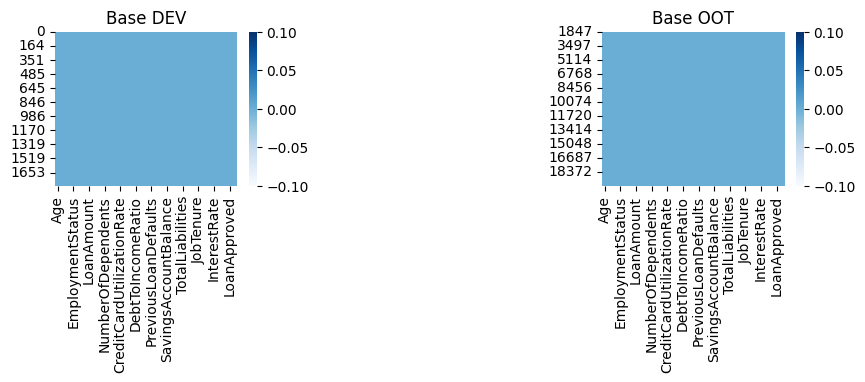

In [27]:
plt.figure(figsize = (10, 2))

plt.subplot(1, 3, 1)
plt.title("Base DEV")
sns.heatmap(dev.isnull(), cmap='Blues')

plt.subplot(1, 3, 3)
plt.title("Base OOT")
sns.heatmap(oot.isnull(), cmap='Blues')
plt.show()

### 02. Avaliação de Colunas

In [7]:
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,2.000000e+04,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,3.625241e+04,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,4.725151e+04,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,3.720000e+02,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,1.119675e+04,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,2.220300e+04,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,4.314650e+04,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,1.417302e+06,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  int64  
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              20000 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               20000 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     20000 no

O Dataset contém 36 colunas e 20.000 linhas, dentre as colunas é possivel identificar colunas catégoricas que necessitam de tratamento para que possam ser corretamente interpretadas por algoritmos de machine learning.

Variáveis categoricas:
* EmploymentStatus
* EducationLevel
* MaritalStatus
* HomeOwnershipStatus
* LoanPurpose

### 03. Análise de Variáveis Numéricas

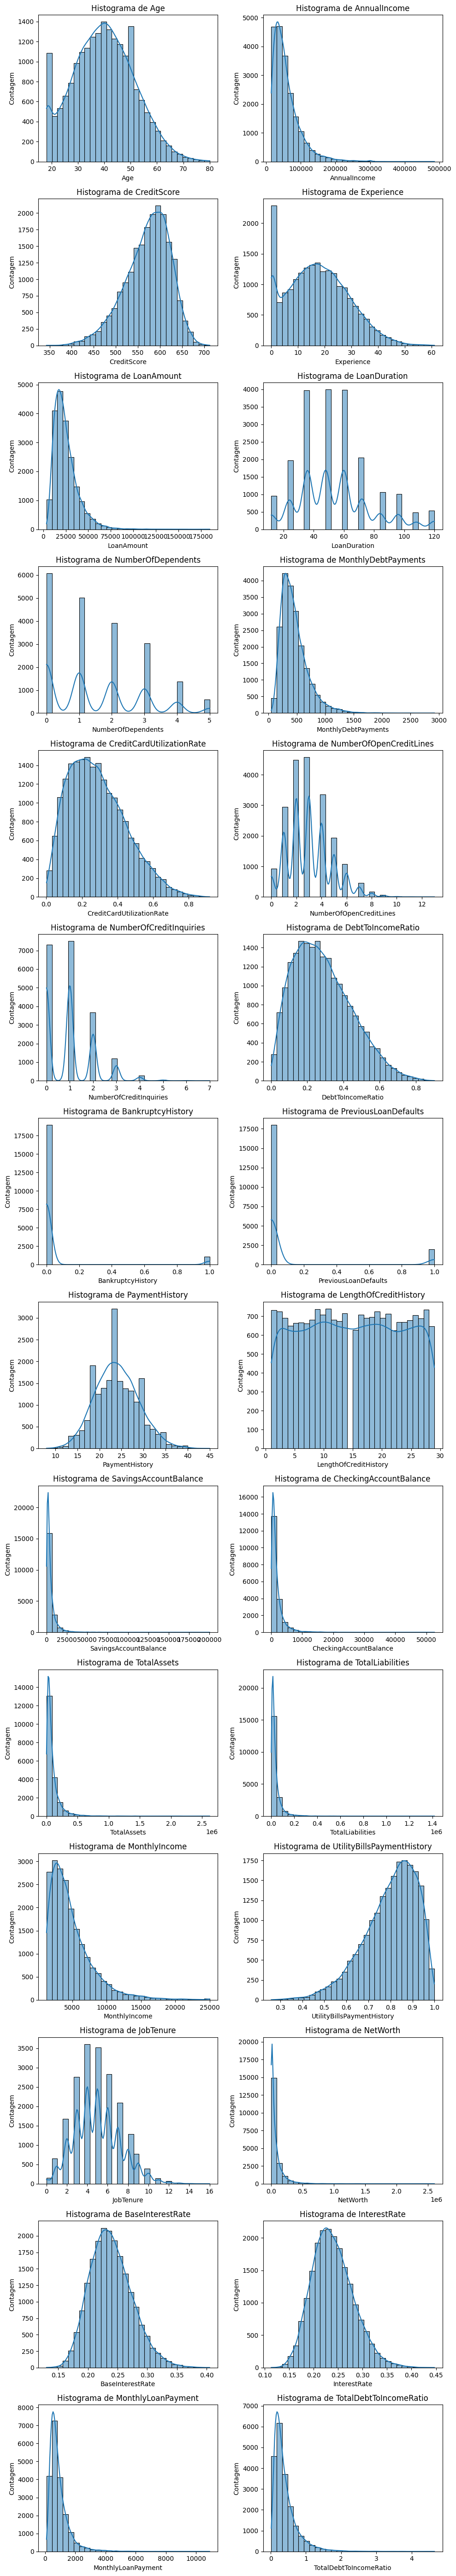

In [9]:
num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns

num_plots = len(num_cols)
num_cols_grid = 2
num_rows_grid = (num_plots + num_cols_grid - 1) // num_cols_grid

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(10, num_rows_grid * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Contagem')
    axes[i].set_title(f'Histograma de {col}')

plt.tight_layout()
plt.show()

### 04. Análise de Variáveis Categóricas

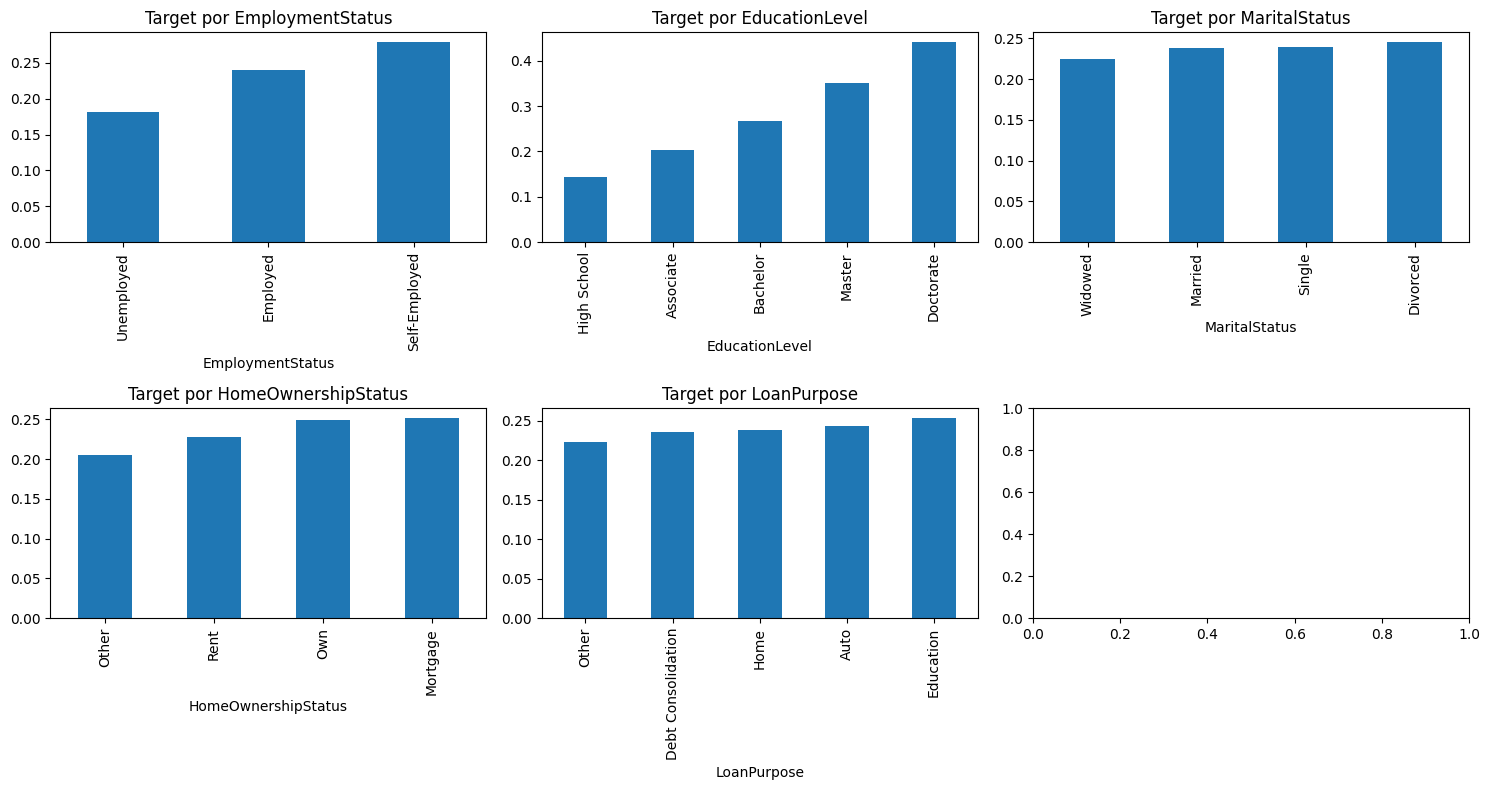

In [10]:

categ_cols = X_train.select_dtypes(include=["object", "category"]).columns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(categ_cols):
    ax = axes[i]
    df.groupby(col)["LoanApproved"].mean().sort_values().plot(kind="bar",ax=ax)
    ax.set_title(f"Target por {col}")

plt.tight_layout()
plt.show()

In [11]:
iv = sc.iv(train, y="LoanApproved")

categ_final = iv[
    (iv["variable"].isin(categ_cols)) &
    (iv["info_value"] >= 0.02)
]["variable"].tolist()

In [12]:
categ_final

['EducationLevel', 'HomeOwnershipStatus', 'EmploymentStatus', 'LoanPurpose']

Das principais informações desses dataframe (Renda Mensal, Valor do Empréstimo e Prazo) é possivel avaliar que:

A mediana da renda mensal é de 4.034
O valor médio emprestado é de 24.882
A média de tempo para um empréstimo é de 54 meses, com metade dos empréstimos com vencimento de 48 meses

### 05. Seleção de Variáveis

Utilizou-se o IV (Information Value) como método inicial de seleção de variáveis, uma vez que, ele permite identificar variáveis com maior capacidade de discriminar entre bons e maus, ou seja, as que melhor explicam a variável alvo (0/1).

Em seguida, o PSI (Population Stability Index) foi aplicado para medir a variação na distribuição das variáveis ao longo do tempo, capturando possíveis mudanças no comportamento da população.

Por fim, o coeficiente de Correlação de Pearson foi utilizado para quantificar a força e a direção da relação linear entre variáveis contínuas, auxiliando na remoção de variáveis altamente correlacionadas e contribuindo para a redução de overfitting no modelo.

In [13]:
def calc_psi(train_col, oot_col, bins=10):

    if train_col.dtype != "object":
        breakpoints = np.percentile(train_col, np.linspace(0, 100, bins+1))
        train_col = pd.cut(train_col, bins=breakpoints, duplicates='drop')
        oot_col = pd.cut(oot_col, bins=breakpoints, duplicates='drop')

    train_dist = train_col.value_counts(normalize=True)
    oot_dist = oot_col.value_counts(normalize=True)

    dist = pd.concat([train_dist, oot_dist], axis=1).fillna(1e-6)

    psi = np.sum((dist.iloc[:,0] - dist.iloc[:,1]) * np.log(dist.iloc[:,0] / dist.iloc[:,1]))

    return psi

In [14]:
# IV
iv = sc.iv(train, y="LoanApproved")
iv_vars = iv[iv["info_value"] > 0.02]["variable"].tolist()

# PSI
psi_df = pd.DataFrame({
    "feature": iv_vars,
    "psi": [calc_psi(train[col], oot[col]) for col in iv_vars]
})

vars = psi_df[psi_df["psi"] < 0.25]["feature"].tolist()

# Correlação
num_cols = train[vars].select_dtypes(exclude=["object"]).columns

corr = train[num_cols].corr()
alta_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in alta_corr.columns if any(alta_corr[col] > 0.7)]

final_vars = [col for col in vars if col not in to_drop]

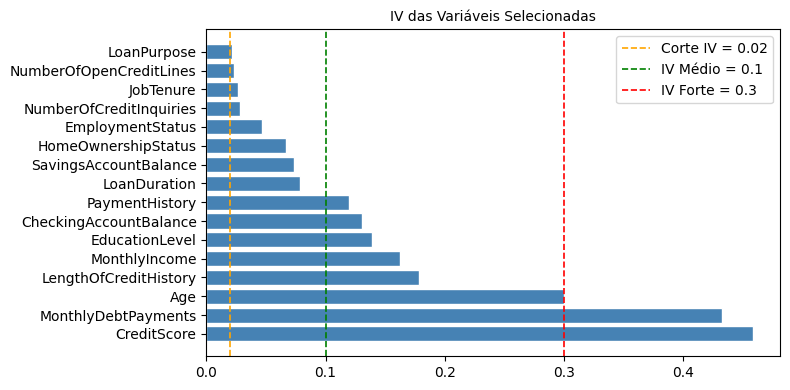

In [15]:
iv_plot = iv[iv["variable"].isin(final_vars)].sort_values("info_value", ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.barh(iv_plot["variable"], iv_plot["info_value"], color="steelblue", edgecolor="white")
plt.axvline(x=0.02, color="orange", linestyle="--", linewidth=1.2, label="Corte IV = 0.02")
plt.axvline(x=0.1,  color="green",  linestyle="--", linewidth=1.2, label="IV Médio = 0.1")
plt.axvline(x=0.3,  color="red",    linestyle="--", linewidth=1.2, label="IV Forte = 0.3")
plt.title("IV das Variáveis Selecionadas", fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
X_train = train[final_vars].copy()
y_train = train["LoanApproved"].copy()

X_vali  = vali[final_vars].copy()
y_vali  = vali["LoanApproved"].copy()

X_oot   = oot[final_vars].copy()
y_oot   = oot["LoanApproved"].copy()

In [17]:
categ_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numer_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Categóricas selecionadas : {categ_cols}")
print(f"Numéricas selecionadas   : {numer_cols}")

Categóricas selecionadas : ['EducationLevel', 'HomeOwnershipStatus', 'EmploymentStatus', 'LoanPurpose']
Numéricas selecionadas   : ['CreditScore', 'MonthlyDebtPayments', 'Age', 'LengthOfCreditHistory', 'MonthlyIncome', 'CheckingAccountBalance', 'PaymentHistory', 'LoanDuration', 'SavingsAccountBalance', 'NumberOfCreditInquiries', 'JobTenure', 'NumberOfOpenCreditLines']


Por último, as variáveis categóricas finais foram tratadas com agrupamento via OneHotEncoder, além da padronização por StandardScaler para as variáveis numéricas, garantindo que todas as features fossem representadas em escala adequada.

In [18]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(),                                             numer_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),  categ_cols)
])

preprocess.fit(X_train)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['CreditScore', 'MonthlyDebtPayments', 'Age',
                                  'LengthOfCreditHistory', 'MonthlyIncome',
                                  'CheckingAccountBalance', 'PaymentHistory',
                                  'LoanDuration', 'SavingsAccountBalance',
                                  'NumberOfCreditInquiries', 'JobTenure',
                                  'NumberOfOpenCreditLines']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['EducationLevel', 'HomeOwnershipStatus',
                                  'EmploymentStatus', 'LoanPurpose'])])

### 06. Treino dos Modelos

Os modelos utilizados foram a Regressão Logística, LightGBM (LGBM Classifier) e XGBoost (eXtreme Gradient Boosting), ambos amplamente utilizados em problemas de risco de crédito e aprovação de empréstimos.

A Regressão Logística é um modelo linear de classificação binária que estima a probabilidade de inadimplência ou aprovação, sobre a chance de crédito ser concedido.

O LightGBM e o XGBoost são algoritmos de gradient boosting baseados em árvores de decisão, capazes de capturar relações não lineares e interações complexas entre variáveis financeiras e comportamentais, sendo amplamente utilizados para cenários de crédito com grande volume de dados e múltiplos atributos do cliente.

In [19]:
pipeline_logr = Pipeline([
    ("prep",  preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

pipeline_logr.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore',
                                                   'MonthlyDebtPayments', 'Age',
                                                   'LengthOfCreditHistory',
                                                   'MonthlyIncome',
                                                   'CheckingAccountBalance',
                                                   'PaymentHistory',
                                                   'LoanDuration',
                                                   'SavingsAccountBalance',
                                                   'NumberOfCreditInquiries',
                                                   'JobTenure',
                                                   'NumberOfOpenCreditLines']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['EducationLevel',
                                                   'HomeOwnershipStatus',
                                                   'EmploymentStatus',
                                                   'LoanPurpose'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [20]:
mod_lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    is_unbalance=True,
    random_state=42,
    verbose=-1
)

pipeline_lgbm = Pipeline([
    ("prep",  preprocess),
    ("model", mod_lgbm)
])

pipeline_lgbm.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore',
                                                   'MonthlyDebtPayments', 'Age',
                                                   'LengthOfCreditHistory',
                                                   'MonthlyIncome',
                                                   'CheckingAccountBalance',
                                                   'PaymentHistory',
                                                   'LoanDuration',
                                                   'SavingsAccountBalance',
                                                   'NumberOfCreditInquiries',
                                                   'JobTenure',
                                                   'NumberOfOpenCreditLines']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['EducationLevel',
                                                   'HomeOwnershipStatus',
                                                   'EmploymentStatus',
                                                   'LoanPurpose'])])),
                ('model',
                 LGBMClassifier(is_unbalance=True, learning_rate=0.05,
                                max_depth=6, n_estimators=300, random_state=42,
                                verbose=-1))])

In [21]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos

mod_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale)

pipeline_xgb = Pipeline([
    ("prep",  preprocess),
    ("model", mod_xgb)
])

pipeline_xgb.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore',
                                                   'MonthlyDebtPayments', 'Age',
                                                   'LengthOfCreditHistory',
                                                   'MonthlyIncome',
                                                   'CheckingAccountBalance',
                                                   'PaymentHistory',
                                                   'LoanDuration',
                                                   'SavingsAccountBalance',
                                                   'NumberOfCreditInquiries',
                                                   'JobTenure',
                                                   'NumberOfOpenCreditLines']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ign...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

### 07. Performance dos Modelos

In [22]:
modelos = {
    "Regressão Logística": pipeline_logr,
    "LightGBM":            pipeline_lgbm,
    "XGBoost":             pipeline_xgb
          }

def ks_stat(y_true, y_prob):
    return ks_2samp(y_prob[y_true == 0], y_prob[y_true == 1]).statistic

resultados = []
probabilidades = {}

for nome, pipe in modelos.items():
    pipe.fit(X_train, y_train)

    for base_nome, X, y in [("Treino", X_train, y_train),
                             ("Validação",  X_vali,  y_vali),
                             ("OOT",   X_oot,   y_oot)]:
        prob = pipe.predict_proba(X)[:, 1]
        auc  = roc_auc_score(y, prob)
        ks   = ks_stat(y.values, prob)
        resultados.append({"Modelo": nome, "Base": base_nome,
                           "AUC": auc, "KS": ks})

    probabilidades[nome] = {
        "Treino": (y_train, pipe.predict_proba(X_train)[:, 1]),
        "Validação":  (y_vali,  pipe.predict_proba(X_vali)[:,  1]),
        "OOT":   (y_oot,   pipe.predict_proba(X_oot)[:,   1]),
    }

df_resultados = pd.DataFrame(resultados)

print("=" * 58)
print(f"{'Modelo':<25} {'Base':<8} {'AUC':>8} {'KS':>8}")
print("=" * 58)
for _, row in df_resultados.iterrows():
    print(f"{row['Modelo']:<25} {row['Base']:<8} "
          f"{row['AUC']:>8.4f} {row['KS']:>8.4f}")
    if row['Base'] == "OOT":
        print("-" * 58)
print("=" * 58)

Modelo                    Base          AUC       KS
Regressão Logística       Treino     0.9214   0.6869
Regressão Logística       Validação   0.8491   0.5334
Regressão Logística       OOT        0.9017   0.6402
----------------------------------------------------------
LightGBM                  Treino     1.0000   1.0000
LightGBM                  Validação   0.8405   0.5464
LightGBM                  OOT        0.8917   0.6192
----------------------------------------------------------
XGBoost                   Treino     1.0000   1.0000
XGBoost                   Validação   0.8344   0.5090
XGBoost                   OOT        0.8910   0.6191
----------------------------------------------------------


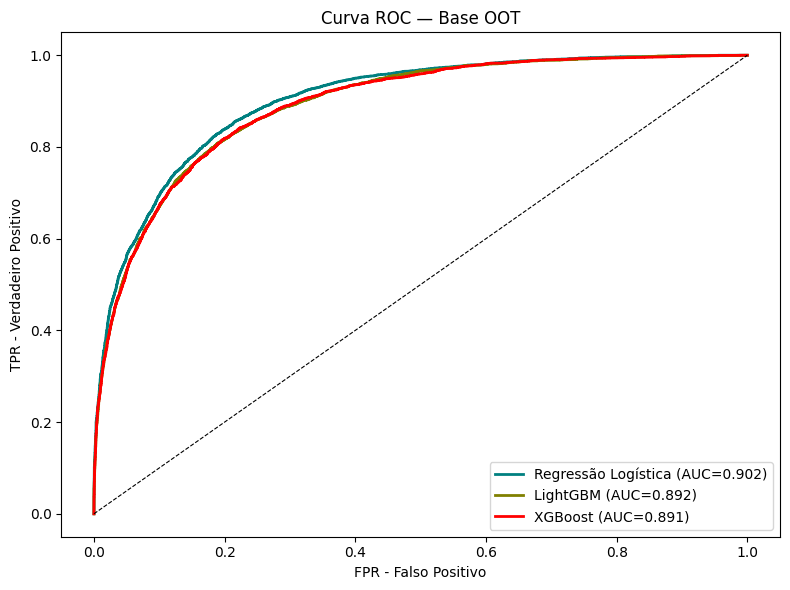

In [23]:
bases  = ["Treino", "Validação", "OOT"]
nomes  = list(modelos.keys())
cores  = ["teal", "olive", "red"]
width  = 0.25
x      = np.arange(len(bases))

plt.figure(figsize=(8, 6))
for nome, cor in zip(nomes, cores):
    y_true, y_prob = probabilidades[nome]["OOT"]
    fpr, tpr, _    = roc_curve(y_true, y_prob)
    auc            = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, color=cor, linewidth=2, label=f"{nome} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.title("Curva ROC — Base OOT")
plt.xlabel("FPR - Falso Positivo")
plt.ylabel("TPR - Verdadeiro Positivo")
plt.legend()
plt.tight_layout()
plt.show()

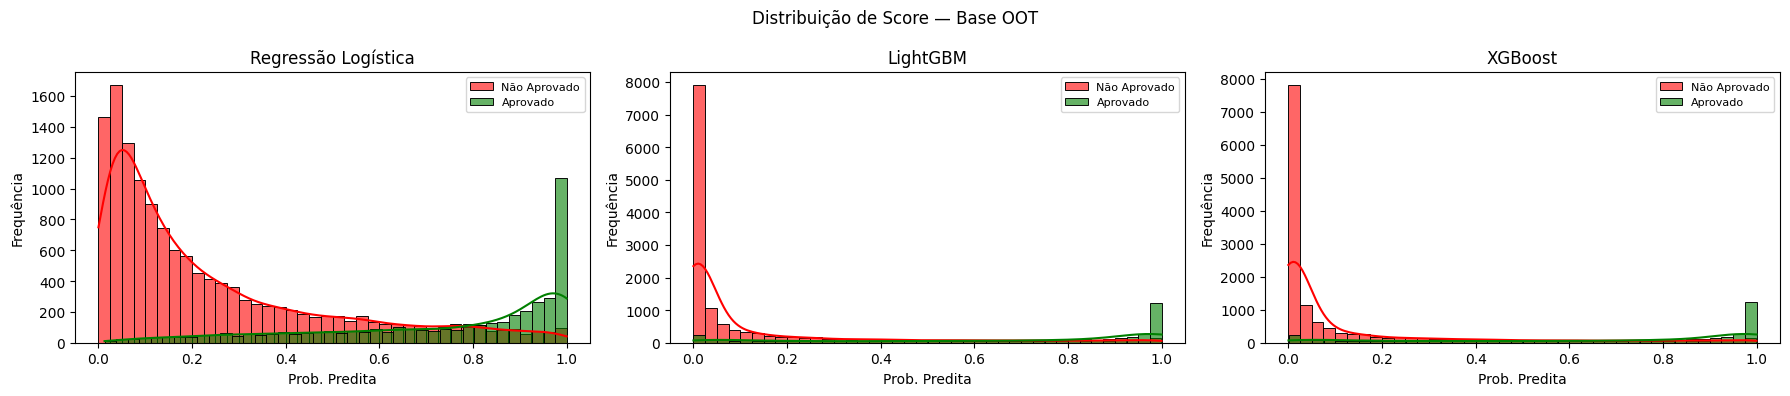

In [24]:
fig, axes = plt.subplots(1, len(nomes), figsize=(6 * len(nomes), 4))

for ax, (nome, cor) in zip(axes, zip(nomes, cores)):
    y_true, y_prob = probabilidades[nome]["OOT"]
    sns.histplot(y_prob[y_true == 0], bins=40, kde=True, ax=ax,
                 color="r", label="Não Aprovado", alpha=0.6)
    sns.histplot(y_prob[y_true == 1], bins=40, kde=True, ax=ax,
                 color="g", label="Aprovado", alpha=0.6)
    ax.set_title(nome)
    ax.set_xlabel("Prob. Predita")
    ax.set_ylabel("Frequência")
    ax.legend(fontsize=8)

plt.suptitle("Distribuição de Score — Base OOT")
plt.tight_layout()
plt.show()

### 08. SHAP

SHAP (SHapley Additive exPlanations) é um metodo de explicabilidade que possibilita demonstrar o quanto cada feature aumenta ou reduz a probabilidade de impacto na target. Auxiliando na interpretação de cada variavel e seu real impacto no modelo.

No gráfico beeswarm, a cor vermelha representa valores altos da variável que aumentam a chance de aprovação, enquanto a cor azul indica valores baixos, que reduzem ou têm menor impacto na aprovação do crédito. Quanto maior o valor de SHAP, maior o impacto dessa variável no resultado do modelo.

In [25]:
X_oot_transformed = pipeline_lgbm.named_steps["prep"].transform(X_oot)

ohe_features  = pipeline_lgbm.named_steps["prep"]\
                    .named_transformers_["cat"]\
                    .get_feature_names_out(categ_cols).tolist()
feature_names = numer_cols + ohe_features

X_oot_df = pd.DataFrame(X_oot_transformed, columns=feature_names)

explainer   = shap.TreeExplainer(pipeline_lgbm.named_steps["model"])
shap_values = explainer.shap_values(X_oot_df)

shap_vals = shap_values

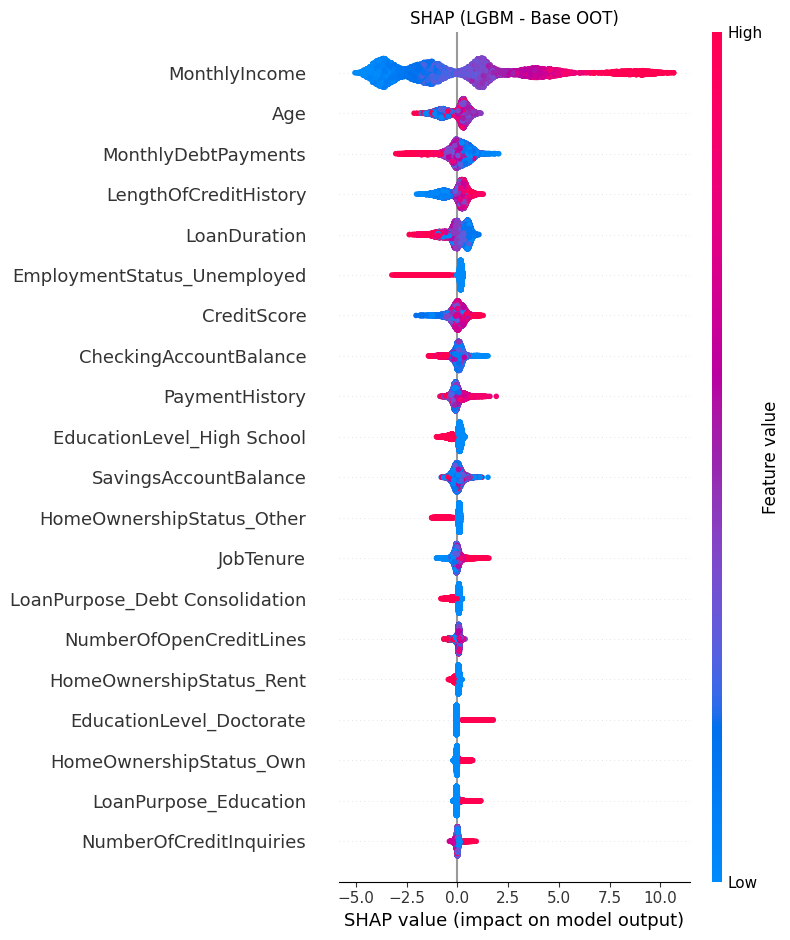

In [26]:
plt.figure( figsize=(10, 6))
shap.summary_plot(
    shap_vals,
    X_oot_df,
    show=False)

plt.title("SHAP (LGBM - Base OOT)")
plt.tight_layout()
plt.show()


Para o modelo testado podemos observar que a variavel MonthlyIncome aparece com alto SHAP, sendo assim a renda mensal a variavel que mais impacta na probabilidade de aprovação. As demais variaveis como CreditScore, PaymentHistory e JobTenure também contribuem fortemente, mostrando que o modelo está capturando bem o risco de inadimplência.

### 09. Conclusão

Com base nas análises realizadas e nos resultados obtidos, o modelo selecionado foi o LightGBM. Além de apresentar excelente desempenho em termos de AUC, o modelo demonstrou maior estabilidade de KS entre as bases de validação e out-off-time, indicando boa capacidade de generalização ao longo do tempo.


---

Aluno: Maria Rita de Sousa

Pontifícia Universidade Católica do Rio de Janeiro

Curso de Pós Graduação Business Intelligence Master